<a href="https://colab.research.google.com/github/ViC3nte1/Pengolahan_Citra/blob/main/Jobsheet_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Transformasi Kurva (Citra *Negatif*)

Citra negatif yang dihasilkan menampilkan tonal yang terbalik dari citra asli. Area yang semula terang menjadi gelap, dan area gelap menjadi terang. Transformasi kurva seperti ini tidak mengubah detail spasial, namun mengubah tampilan visual citra.

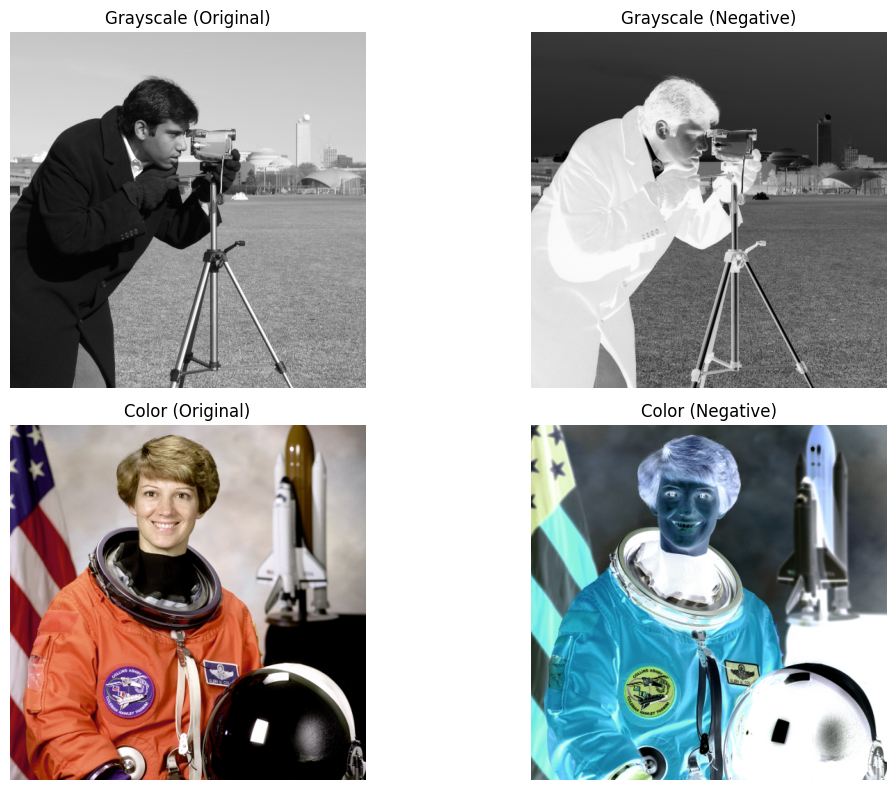

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float

image_gray_uint8 = data.camera()
image_gray_float = img_as_float(image_gray_uint8)
negative_gray = 1.0 - image_gray_float

image_color_uint8 = data.astronaut()
image_color_float = img_as_float(image_color_uint8)
negative_color = 1.0 - image_color_float

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].imshow(image_gray_float, cmap='gray')
axes[0, 0].set_title("Grayscale (Original)")
axes[0, 0].axis('off')
axes[0, 1].imshow(negative_gray, cmap='gray')
axes[0, 1].set_title("Grayscale (Negative)")
axes[0, 1].axis('off')

axes[1, 0].imshow(image_color_float)
axes[1, 0].set_title("Color (Original)")
axes[1, 0].axis('off')

axes[1, 1].imshow(negative_color)
axes[1, 1].set_title("Color (Negative)")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

###Histogram dan Ekualisasi Histogram (Grayscale)

Setelah dilakukan ekualisasi histogram, kontras citra meningkat terutama pada bagian-bagian yang tadinya gelap. . Histogram citra hasil ekualisasi tersebar lebih merata di seluruh rentang intensitas, tidak lagi terkumpul di ujung bawah saja. Ini menandakan rentang intensitas yang tadinya sempit telah diperlebar. Dengan kata lain, ekualisasi histogram berhasil meratakan distribusi intensitas sehingga area gelap menjadi lebih terang dan area terang sedikit lebih gelap, menghasilkan citra dengan detail yang lebih kaya.

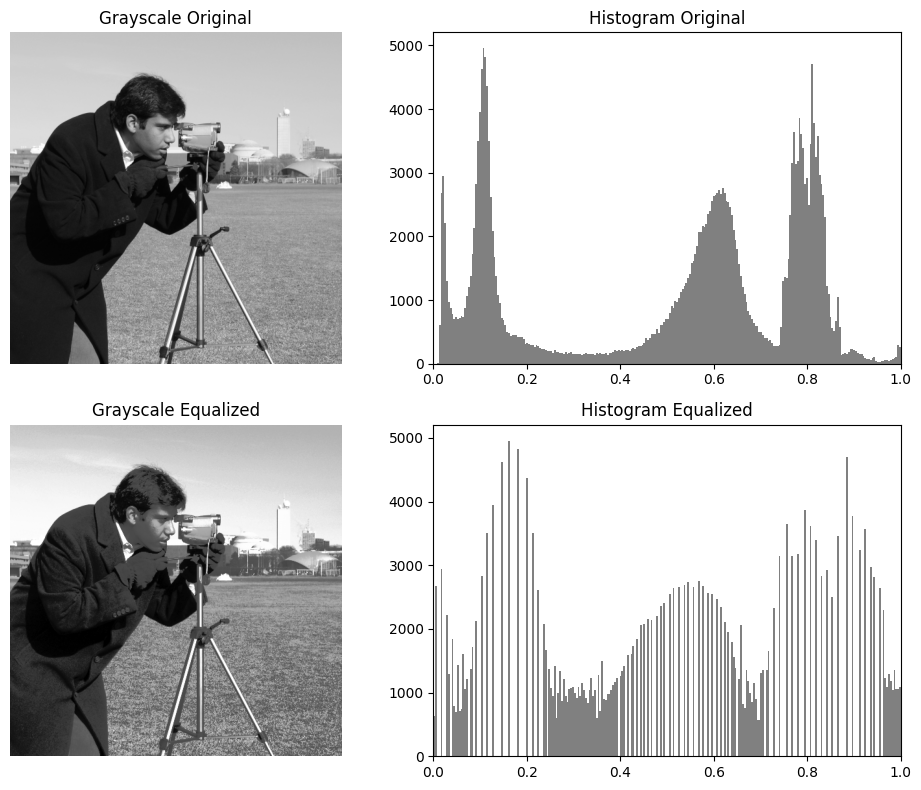

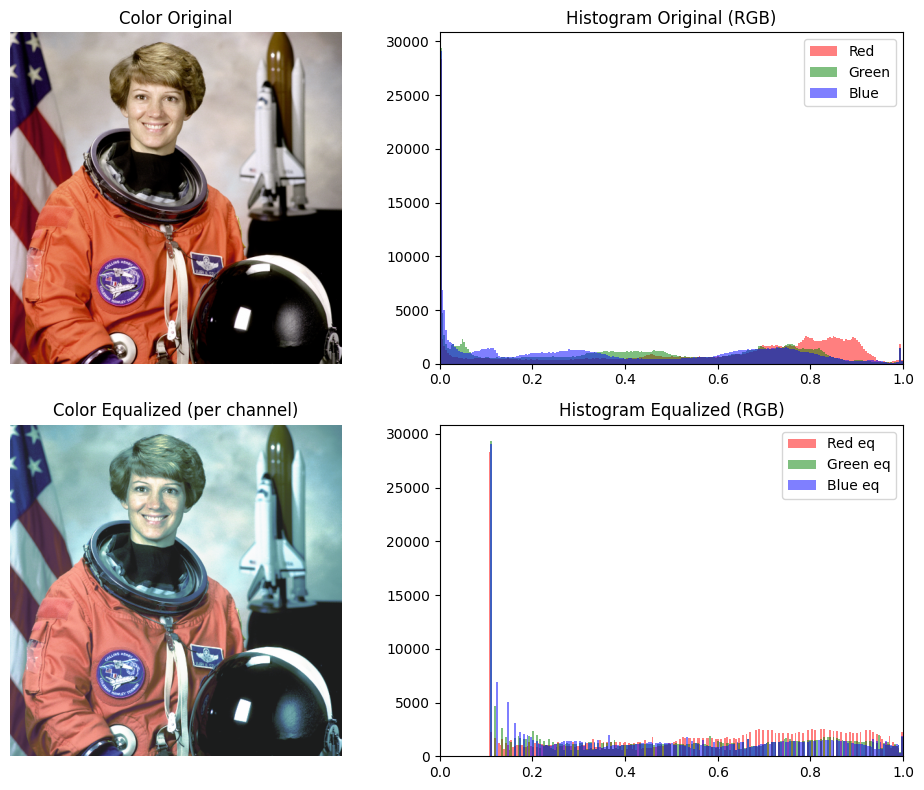

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, exposure, img_as_float

image_gray_uint8 = data.camera()
image_gray = img_as_float(image_gray_uint8)
hist_gray, bins_gray = np.histogram(image_gray.ravel(), bins=256, range=(0,1))

image_gray_eq = exposure.equalize_hist(image_gray)
hist_gray_eq, bins_gray_eq = np.histogram(image_gray_eq.ravel(), bins=256, range=(0,1))
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].imshow(image_gray, cmap='gray')
axes[0, 0].set_title("Grayscale Original")
axes[0, 0].axis('off')

axes[0, 1].hist(image_gray.ravel(), bins=256, range=(0,1), color='gray')
axes[0, 1].set_title("Histogram Original")
axes[0, 1].set_xlim(0,1)

axes[1, 0].imshow(image_gray_eq, cmap='gray')
axes[1, 0].set_title("Grayscale Equalized")
axes[1, 0].axis('off')

axes[1, 1].hist(image_gray_eq.ravel(), bins=256, range=(0,1), color='gray')
axes[1, 1].set_title("Histogram Equalized")
axes[1, 1].set_xlim(0,1)

plt.tight_layout()
plt.show()

# -------------------------------------------------------
# BAGIAN 2: HISTOGRAM & EKUALISASI HISTOGRAM (CITRA WARNA)
# -------------------------------------------------------

image_color_uint8 = data.astronaut()
image_color = img_as_float(image_color_uint8)

r_channel = image_color[:,:,0]
g_channel = image_color[:,:,1]
b_channel = image_color[:,:,2]

hist_r, bins_r = np.histogram(r_channel.ravel(), bins=256, range=(0,1))
hist_g, bins_g = np.histogram(g_channel.ravel(), bins=256, range=(0,1))
hist_b, bins_b = np.histogram(b_channel.ravel(), bins=256, range=(0,1))

r_eq = exposure.equalize_hist(r_channel)
g_eq = exposure.equalize_hist(g_channel)
b_eq = exposure.equalize_hist(b_channel)

image_color_eq = np.dstack((r_eq, g_eq, b_eq))

hist_r_eq, bins_r_eq = np.histogram(r_eq.ravel(), bins=256, range=(0,1))
hist_g_eq, bins_g_eq = np.histogram(g_eq.ravel(), bins=256, range=(0,1))
hist_b_eq, bins_b_eq = np.histogram(b_eq.ravel(), bins=256, range=(0,1))

fig2, axes2 = plt.subplots(2, 2, figsize=(10, 8))
axes2[0, 0].imshow(image_color)
axes2[0, 0].set_title("Color Original")
axes2[0, 0].axis('off')

axes2[0, 1].hist(r_channel.ravel(), bins=256, range=(0,1), color='red', alpha=0.5, label='Red')
axes2[0, 1].hist(g_channel.ravel(), bins=256, range=(0,1), color='green', alpha=0.5, label='Green')
axes2[0, 1].hist(b_channel.ravel(), bins=256, range=(0,1), color='blue', alpha=0.5, label='Blue')
axes2[0, 1].set_title("Histogram Original (RGB)")
axes2[0, 1].set_xlim(0,1)
axes2[0, 1].legend(loc='upper right')

axes2[1, 0].imshow(image_color_eq)
axes2[1, 0].set_title("Color Equalized (per channel)")
axes2[1, 0].axis('off')

axes2[1, 1].hist(r_eq.ravel(), bins=256, range=(0,1), color='red', alpha=0.5, label='Red eq')
axes2[1, 1].hist(g_eq.ravel(), bins=256, range=(0,1), color='green', alpha=0.5, label='Green eq')
axes2[1, 1].hist(b_eq.ravel(), bins=256, range=(0,1), color='blue', alpha=0.5, label='Blue eq')
axes2[1, 1].set_title("Histogram Equalized (RGB)")
axes2[1, 1].set_xlim(0,1)
axes2[1, 1].legend(loc='upper right')

plt.tight_layout()
plt.show()


###Konvolusi (Filter Rata-rata)

Penerapan filter rata-rata 5×5 pada citra menghasilkan efek smoothing yang jelas terlihat. Citra output tampak lebih kabur dibanding citra original – tepi objek menjadi kurang tajam dan tekstur halus tersamar. Hal ini terjadi karena konvolusi dengan kernel rata-rata menghitung nilai piksel keluaran sebagai rata-rata dari tetangga sekitarnya, sehingga perbedaan ekstrem dihaluskan. Keuntungan dari smoothing ini adalah derau acak atau detail kecil yang tidak diinginkan berkurang. Namun, trade-off-nya adalah kehilangan ketajaman pada tepi objek. Dengan kata lain, filter linear sederhana seperti rata-rata mengorbankan ketajaman demi mengurangi noise. Filter ini berguna untuk prapemrosesan

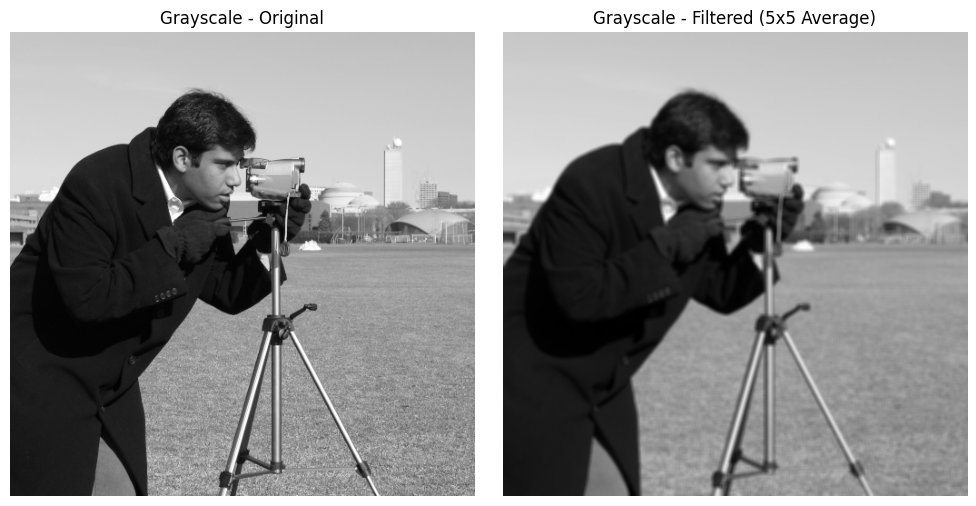

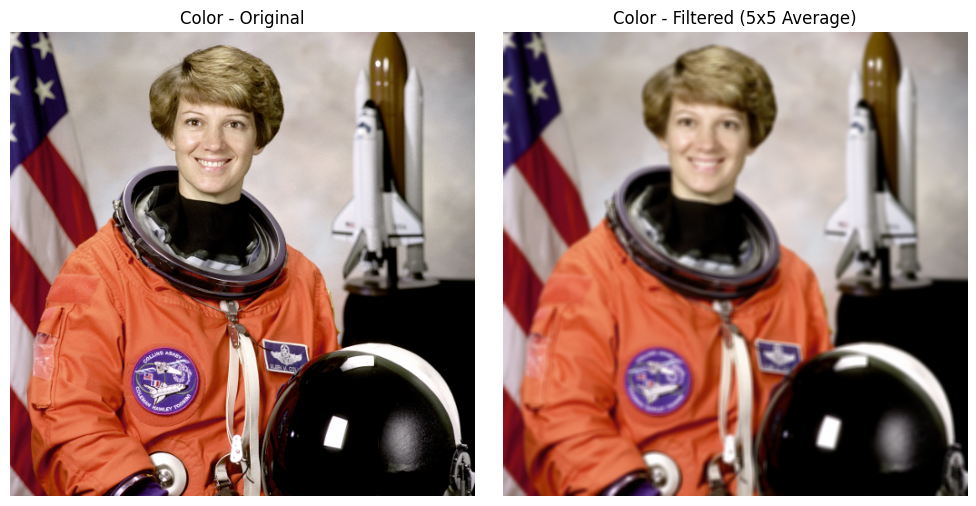

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from scipy import ndimage as ndi

gray_uint8 = data.camera()
gray_img = img_as_float(gray_uint8)

kernel_size = 5
kernel = np.ones((kernel_size, kernel_size), dtype=float) / (kernel_size * kernel_size)
gray_filtered = ndi.convolve(gray_img, kernel, mode='reflect')

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(gray_img, cmap='gray')
axes[0].set_title("Grayscale - Original")
axes[0].axis('off')

axes[1].imshow(gray_filtered, cmap='gray')
axes[1].set_title(f"Grayscale - Filtered ({kernel_size}x{kernel_size} Average)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

# --------------------------------------------------
# 2) FILTER RATA-RATA PADA CITRA BERWARNA
# --------------------------------------------------

color_uint8 = data.astronaut()
color_img = img_as_float(color_uint8)
color_filtered = np.zeros_like(color_img)

for c in range(3):  # c = 0 (Red), 1 (Green), 2 (Blue)
    channel_original = color_img[:, :, c]
    channel_filtered = ndi.convolve(channel_original, kernel, mode='reflect')
    color_filtered[:, :, c] = channel_filtered

fig2, axes2 = plt.subplots(1, 2, figsize=(10, 5))
axes2[0].imshow(color_img)
axes2[0].set_title("Color - Original")
axes2[0].axis('off')

axes2[1].imshow(color_filtered)
axes2[1].set_title(f"Color - Filtered ({kernel_size}x{kernel_size} Average)")
axes2[1].axis('off')

plt.tight_layout()
plt.show()

###Filter Median (Penghilang Noise / Derau)

Hasil penyaringan dengan filter median menunjukkan derau salt-and-pepper berhasil dihilangkan secara efektif. Pada citra berderau, terdapat banyak piksel hitam dan putih acak yang mengganggu (misalnya bintik putih di area gelap dan bintik hitam di area terang). Setelah filtrasi median, bintik-bintik tersebut hampir seluruhnya hilang, sementara detail citra (termasuk tepi objek) relatif terjaga. Filter median sangat cocok untuk membersihkan derau impuls pada citra sebelum tahap pengolahan lebih lanjut (misalnya sebelum segmentasi atau deteksi tepi), tanpa terlalu merusak detail penting.

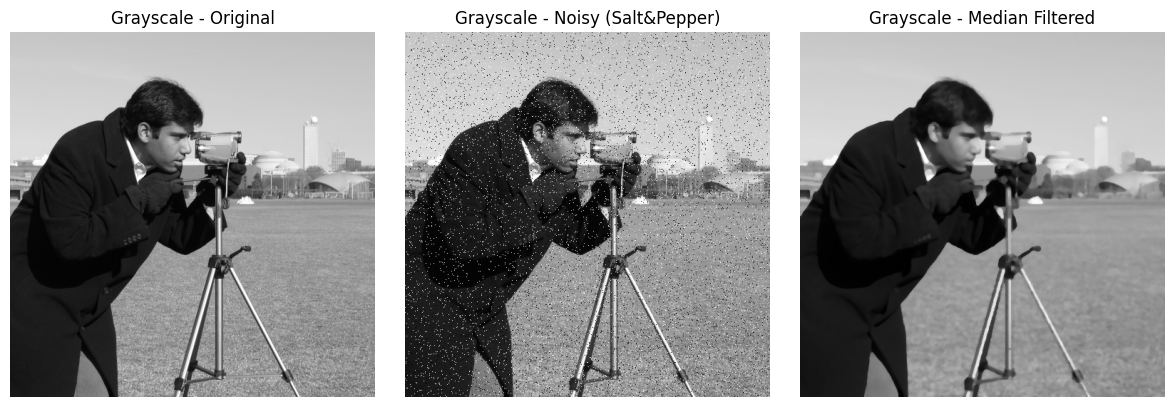

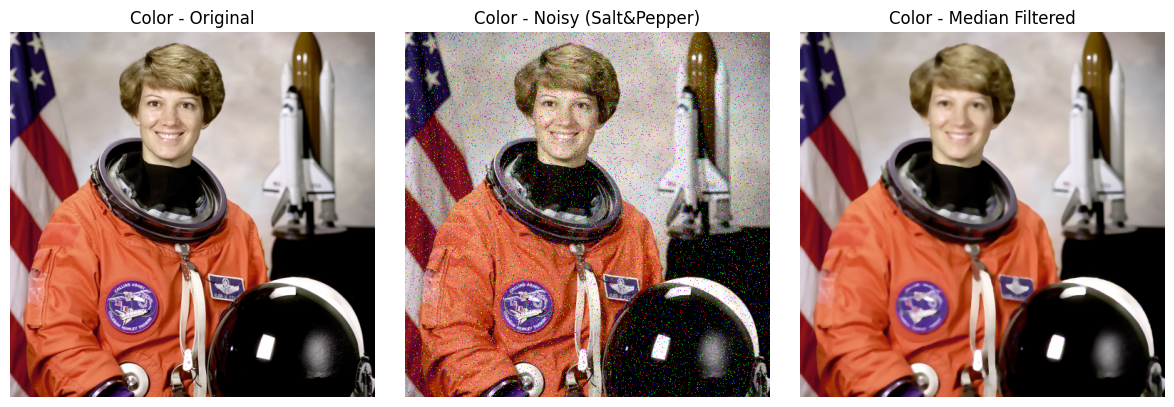

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, util, filters, morphology, img_as_float

gray_uint8 = data.camera()
gray_float = img_as_float(gray_uint8)
gray_noisy = util.random_noise(gray_float, mode='s&p', amount=0.05)

disk3 = morphology.disk(3)
gray_denoised = filters.median(gray_noisy, disk3)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(gray_float, cmap='gray')
axes[0].set_title("Grayscale - Original")
axes[0].axis('off')

axes[1].imshow(gray_noisy, cmap='gray')
axes[1].set_title("Grayscale - Noisy (Salt&Pepper)")
axes[1].axis('off')

axes[2].imshow(gray_denoised, cmap='gray')
axes[2].set_title("Grayscale - Median Filtered")
axes[2].axis('off')

plt.tight_layout()
plt.show()

# -----------------------------------------
# 2) FILTER MEDIAN PADA CITRA BERWARNA
# -----------------------------------------

color_uint8 = data.astronaut()
color_float = img_as_float(color_uint8)

# B. Menambahkan noise salt-and-pepper
color_noisy = util.random_noise(color_float, mode='s&p', amount=0.05)

color_denoised = np.zeros_like(color_noisy)
for c in range(color_noisy.shape[2]):
  color_denoised[:, :, c] = filters.median(color_noisy[:, :, c], morphology.disk(3))

fig2, axes2 = plt.subplots(1, 3, figsize=(12, 4))
axes2[0].imshow(color_float)
axes2[0].set_title("Color - Original")
axes2[0].axis('off')

axes2[1].imshow(color_noisy)
axes2[1].set_title("Color - Noisy (Salt&Pepper)")
axes2[1].axis('off')

axes2[2].imshow(color_denoised)
axes2[2].set_title("Color - Median Filtered")
axes2[2].axis('off')

plt.tight_layout()
plt.show()

###Transformasi Kurva Lain (Gamma)

Pada Transformasi Kurva Gamma ini digunakan untuk merubah kecerahan dari gambar asli menjadi lebih terang atau lebih gelap tergantung pada nilai gamma yang diberikan. Jika nilai Gamma < 1 maka gambar akan menjadi lebih terang, sedangkan jika nilai Gamma > 1 maka gambar akan terlihat lebih gelap.

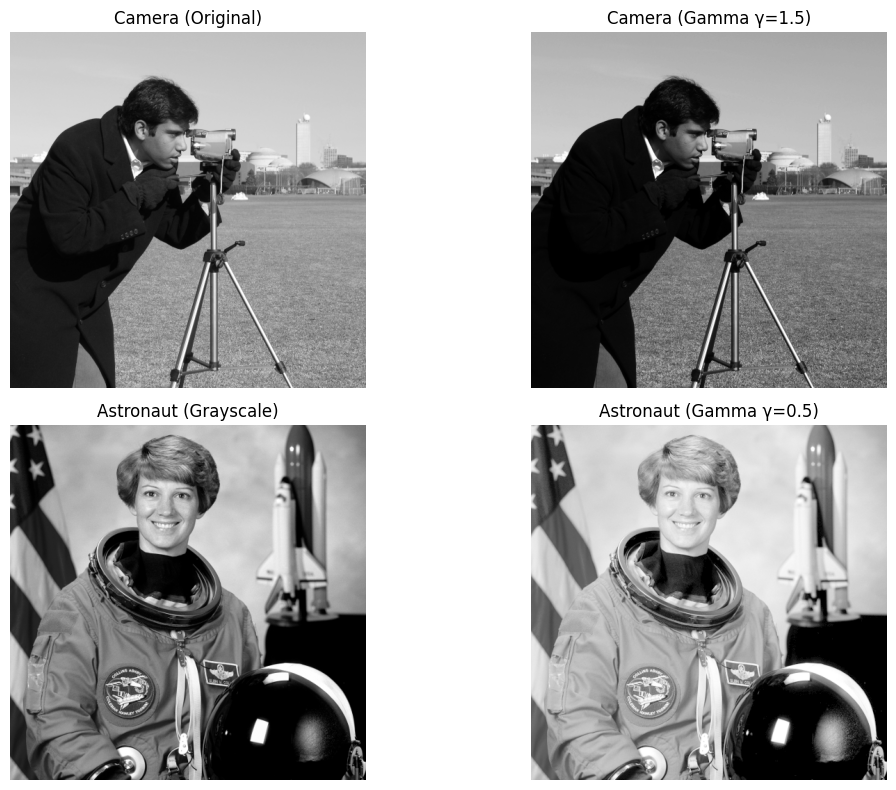

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from skimage.color import rgb2gray
from skimage.exposure import adjust_gamma

# Gambar grayscale (camera)
image_gray_uint8 = data.camera()
image_gray_float = img_as_float(image_gray_uint8)
gamma_gray = adjust_gamma(image_gray_float, gamma=1.5)  # Lebih terang

# Gambar berwarna (astronaut) → ubah ke grayscale
image_color_uint8 = data.astronaut()
image_color_float = img_as_float(image_color_uint8)
image_color_gray = rgb2gray(image_color_float)
gamma_color_gray = adjust_gamma(image_color_gray, gamma=0.5)  # Lebih terang

# Plotting
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].imshow(image_gray_float, cmap='gray')
axes[0, 0].set_title("Camera (Original)")
axes[0, 0].axis('off')

axes[0, 1].imshow(gamma_gray, cmap='gray')
axes[0, 1].set_title("Camera (Gamma γ=1.5)")
axes[0, 1].axis('off')

axes[1, 0].imshow(image_color_gray, cmap='gray')
axes[1, 0].set_title("Astronaut (Grayscale)")
axes[1, 0].axis('off')

axes[1, 1].imshow(gamma_color_gray, cmap='gray')
axes[1, 1].set_title("Astronaut (Gamma γ=0.5)")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()


###Perbandingan Metode Peningkatan Kontras (Contrast Stretching vs Histogram Equalization)

Pada peningkatan contrast antara Contrast Stretching dan Histogram Equalization ini digunakan untuk meningkatkan kontras pada sebuah citra. Agar hasil terlihat lebih jelas gambar akan dirubah intensitas cahanya menggunakan Gamma. Pada hasil terlihat bahwa Contrast Stretching tidak terlihat perubahannya sedangkan pada Histogram Equalization terlihat hasilnya lebih gelap. Pada Contrast Stretching meskipun nilai dari out_range dirubah, yang berubah hanya pada grafiknya saja namun pada gambar tidak terlihat perubahannya.

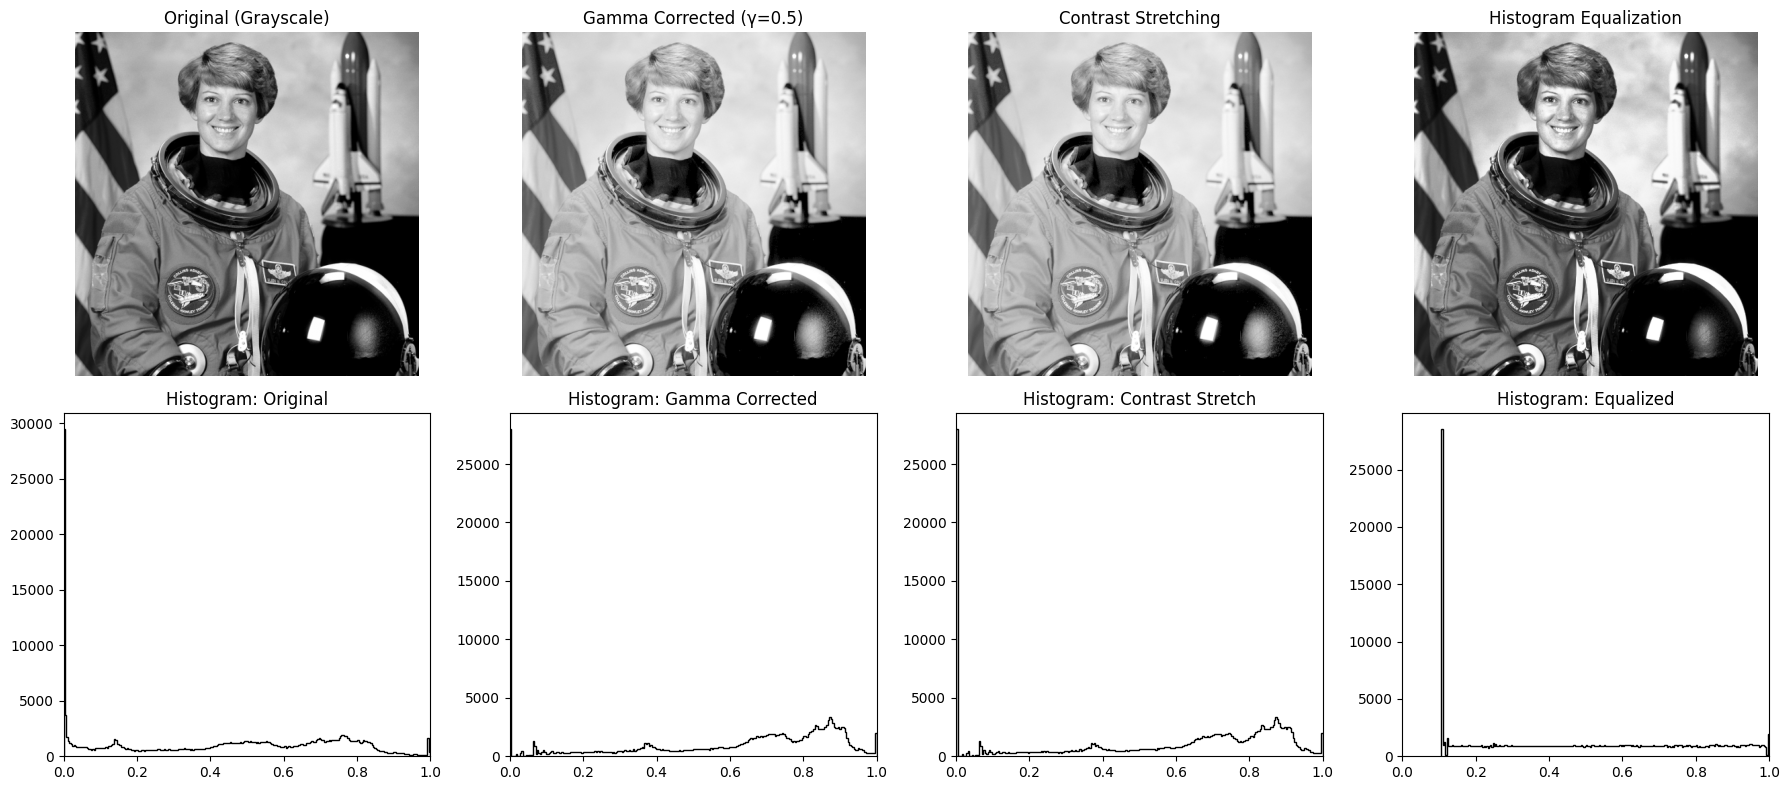

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from skimage.color import rgb2gray
from skimage.exposure import rescale_intensity, equalize_hist, adjust_gamma

def plot_histogram(image, ax, title):
    ax.hist(image.ravel(), bins=256, histtype='step', color='black')
    ax.set_title(title)
    ax.set_xlim(0, 1)

# --- Load and convert astronaut to grayscale ---
image_rgb = data.astronaut()
image_gray = rgb2gray(img_as_float(image_rgb))

# --- Step 1: Gamma Correction ---
gamma_corrected = adjust_gamma(image_gray, gamma=0.5)  # gamma < 1 → lebih terang

# --- Step 2: Contrast Stretching ---
contrast_stretched = rescale_intensity(gamma_corrected, in_range='image', out_range=(0, 1))

# --- Step 3: Histogram Equalization ---
hist_equalized = equalize_hist(gamma_corrected)

# --- Plotting ---
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

# === GAMBAR ===
axes[0, 0].imshow(image_gray, cmap='gray')
axes[0, 0].set_title("Original (Grayscale)")
axes[0, 0].axis('off')

axes[0, 1].imshow(gamma_corrected, cmap='gray')
axes[0, 1].set_title("Gamma Corrected (γ=0.5)")
axes[0, 1].axis('off')

axes[0, 2].imshow(contrast_stretched, cmap='gray')
axes[0, 2].set_title("Contrast Stretching")
axes[0, 2].axis('off')

axes[0, 3].imshow(hist_equalized, cmap='gray')
axes[0, 3].set_title("Histogram Equalization")
axes[0, 3].axis('off')

# === HISTOGRAM ===
plot_histogram(image_gray, axes[1, 0], "Histogram: Original")
plot_histogram(gamma_corrected, axes[1, 1], "Histogram: Gamma Corrected")
plot_histogram(contrast_stretched, axes[1, 2], "Histogram: Contrast Stretch")
plot_histogram(hist_equalized, axes[1, 3], "Histogram: Equalized")

plt.tight_layout()
plt.show()


###Filter Median vs Filter Rata-rata

Pada hasil terlihat bahwa median memiliki hasil lebih jelas karena filter median hanya mengambil nilai tengah dari piksel-piksel tetangga, noise akan diabaikan selama mayoritas tetangga tidak terkena noise, menghasilkan noise impuls bisa dihilangkan tanpa mengaburkan tepi gambar

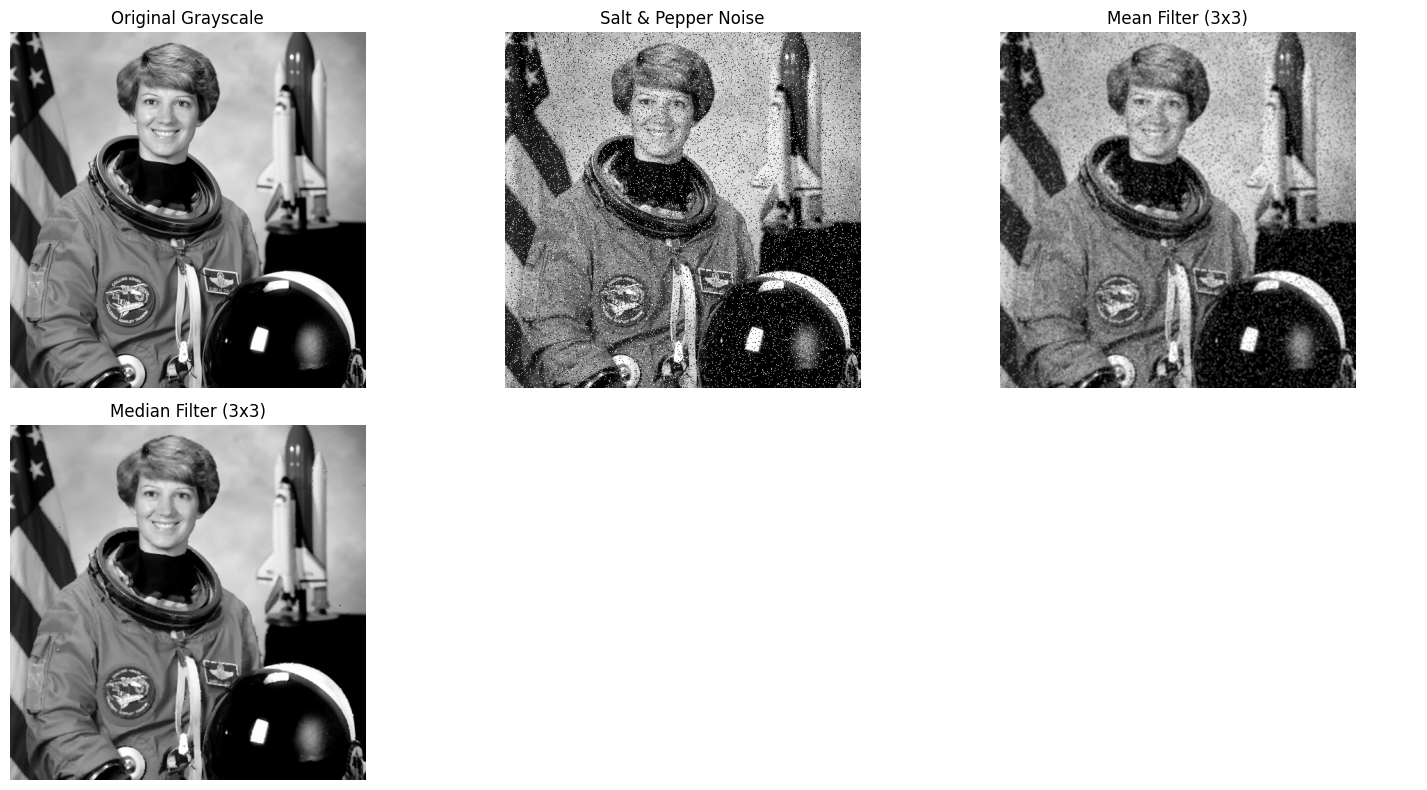

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float, img_as_ubyte
from skimage.color import rgb2gray
from skimage.util import random_noise
from scipy.ndimage import convolve, median_filter

# --- Load image and convert to grayscale ---
image_rgb = data.astronaut()
image_gray = rgb2gray(img_as_float(image_rgb))

# --- Tambahkan noise salt-and-pepper ---
noisy_image = random_noise(image_gray, mode='s&p', amount=0.1)  # 10% noise

# --- Filter rata-rata (mean filter) dengan konvolusi kernel 3x3 ---
kernel = np.ones((3, 3)) / 9
mean_filtered = convolve(noisy_image, kernel)

# --- Filter median (ukuran 3x3) ---
median_filtered = median_filter(noisy_image, size=3)

# --- Plotting ---
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0, 0].imshow(image_gray, cmap='gray')
axes[0, 0].set_title("Original Grayscale")
axes[0, 0].axis('off')

axes[0, 1].imshow(noisy_image, cmap='gray')
axes[0, 1].set_title("Salt & Pepper Noise")
axes[0, 1].axis('off')

axes[0, 2].imshow(mean_filtered, cmap='gray')
axes[0, 2].set_title("Mean Filter (3x3)")
axes[0, 2].axis('off')

axes[1, 0].imshow(median_filtered, cmap='gray')
axes[1, 0].set_title("Median Filter (3x3)")
axes[1, 0].axis('off')

axes[1, 1].axis('off')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()
